In [33]:
import requests, zipfile, io
import pandas as pd

url = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"

print(f"Downloading from {url}...")
r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("./data") # Extracts to a 'data' folder in your current directory

# Load into DataFrame
# Note: The file is inside the 'ml-100k' folder
ratings_df = pd.read_csv("./data/ml-100k/u.data", delimiter='\t', header=None,
                         names=['userId', 'movieId', 'rating', 'timestamp'])

print("Download complete and loaded!")
print(ratings_df.head())

Download complete and loaded!
   userId  movieId  rating  timestamp
0     196      242       3  881250949
1     186      302       3  891717742
2      22      377       1  878887116
3     244       51       2  880606923
4     166      346       1  886397596


In [34]:
import torch
from torch.utils.data import Dataset
import pandas as pd

class MovieLensDataset(Dataset):
    def __init__(self, df):
        # We accept the already loaded DataFrame, so no pd.read_csv here!
        self.df = df.copy()

        # 1. Create Mappings (Raw ID -> Continuous Index)
        self.user_ids = self.df['userId'].unique()
        self.movie_ids = self.df['movieId'].unique()

        # Maps: {Raw_ID : Index}
        self.user_map = {uid: i for i, uid in enumerate(self.user_ids)}
        self.movie_map = {mid: i for i, mid in enumerate(self.movie_ids)}

        # 2. Map the dataframe columns to indices
        self.df['user_idx'] = self.df['userId'].map(self.user_map)
        self.df['movie_idx'] = self.df['movieId'].map(self.movie_map)

        # Convert to tensors
        self.users = torch.tensor(self.df['user_idx'].values, dtype=torch.long)
        self.movies = torch.tensor(self.df['movie_idx'].values, dtype=torch.long)
        self.ratings = torch.tensor(self.df['rating'].values, dtype=torch.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        return self.users[idx], self.movies[idx], self.ratings[idx]

    def get_num_users(self): return len(self.user_ids)
    def get_num_movies(self): return len(self.movie_ids)

In [35]:
import torch.nn as nn

class CollaborativeFilteringModel(nn.Module):
    def __init__(self, n_users, n_movies, n_factors=50, y_range=(0, 5.5)):
        super().__init__()
        self.user_factors = nn.Embedding(n_users, n_factors)
        self.movie_factors = nn.Embedding(n_movies, n_factors)

        self.user_bias = nn.Embedding(n_users, 1)
        self.movie_bias = nn.Embedding(n_movies, 1)
        self.y_range = y_range

        # --- FIX: Add Dropout ---
        self.drop = nn.Dropout(p=0.4) # 20% probability of dropping a neuron

        # Init weights
        self.user_factors.weight.data.uniform_(-0.05, 0.05)
        self.movie_factors.weight.data.uniform_(-0.05, 0.05)
        self.user_bias.weight.data.uniform_(-0.05, 0.05)
        self.movie_bias.weight.data.uniform_(-0.05, 0.05)

    def forward(self, user, movie):
        # Apply dropout to embeddings
        u_emb = self.drop(self.user_factors(user))
        m_emb = self.drop(self.movie_factors(movie))

        dot = (u_emb * m_emb).sum(dim=1)
        res = dot + self.user_bias(user).squeeze() + self.movie_bias(movie).squeeze()
        return torch.sigmoid(res) * (self.y_range[1] - self.y_range[0]) + self.y_range[0]

In [36]:
import torch.optim as optim
import torch.nn as nn

def train_model(model, train_dl, epochs=10, lr=0.01):
    # Move model to GPU if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # Optimizer and Loss
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.1)
    loss_func = nn.MSELoss()

    print(f"Training on {device}...")

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for users, movies, ratings in train_dl:
            # Move data to GPU
            users, movies, ratings = users.to(device), movies.to(device), ratings.to(device)

            # 1. Forward pass
            preds = model(users, movies)

            # 2. Calculate Loss
            loss = loss_func(preds, ratings)

            # 3. Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_dl):.4f}")

    return model

In [37]:
from torch.utils.data import DataLoader, random_split

dataset = MovieLensDataset(ratings_df)

# Split into train/validation
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=64, shuffle=False)

# 2. Setup Model
n_users = dataset.get_num_users()
n_movies = dataset.get_num_movies()
model = CollaborativeFilteringModel(n_users, n_movies)

# 3. Train
model = train_model(model, train_dl, epochs=10, lr=0.005)

Training on cpu...
Epoch 1/10 | Loss: 1.1126
Epoch 2/10 | Loss: 0.8798
Epoch 3/10 | Loss: 0.8268
Epoch 4/10 | Loss: 0.8073
Epoch 5/10 | Loss: 0.7940
Epoch 6/10 | Loss: 0.7905
Epoch 7/10 | Loss: 0.7858
Epoch 8/10 | Loss: 0.7850
Epoch 9/10 | Loss: 0.7797
Epoch 10/10 | Loss: 0.7776


Original Shape: (100, 50)
Reduced Shape: (100, 2)


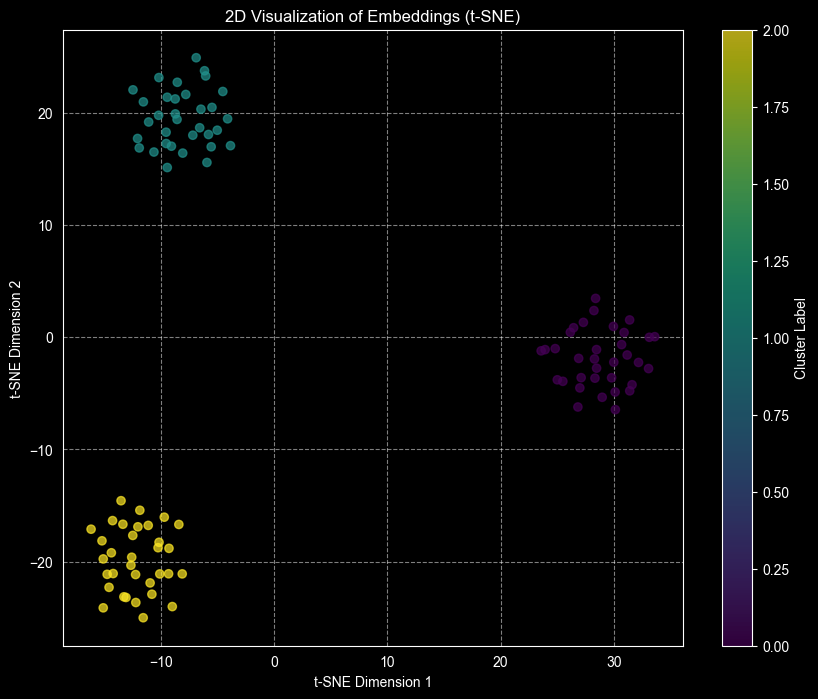

Val RMSE: 0.9221


In [38]:
# 4. Evaluate
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.datasets import make_blobs

# 1. Generate Synthetic Embeddings
# In reality, you would load these from your model (e.g., OpenAI, HuggingFace)
# Creating 100 vectors with 50 dimensions, divided into 3 distinct classes
embeddings, labels = make_blobs(n_samples=100, n_features=50, centers=3, random_state=42)

print(f"Original Shape: {embeddings.shape}") # (100, 50)

# 2. Reduce Dimensions (50 -> 2)
# Perplexity: Related to the number of nearest neighbors.
# usually between 5 and 50. Lower = focuses on very local structure.
tsne = TSNE(n_components=2, perplexity=10, random_state=42, init='pca', learning_rate='auto')
embeddings_2d = tsne.fit_transform(embeddings)

print(f"Reduced Shape: {embeddings_2d.shape}") # (100, 2)

# 3. Plot the Results
plt.figure(figsize=(10, 8))

# Scatter plot: x is column 0, y is column 1
# We color points by their 'label' to see if the clusters separated nicely
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels, cmap='viridis', alpha=0.7)

plt.title('2D Visualization of Embeddings (t-SNE)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.colorbar(scatter, label='Cluster Label')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

def calculate_rmse(model, data_loader, device="cpu"):
    model.eval()
    total_loss = 0
    num_samples = 0

    with torch.no_grad():
        for users, movies, ratings in data_loader:
            users, movies, ratings = users.to(device), movies.to(device), ratings.to(device)
            preds = model(users, movies)
            # Sum of squared errors
            total_loss += ((preds - ratings) ** 2).sum().item()
            num_samples += ratings.size(0)

    # Sqrt(Mean Squared Error)
    return np.sqrt(total_loss / num_samples)

# Usage
print(f"Val RMSE: {calculate_rmse(model, val_dl):.4f}") # Aim for < 1.0